In [27]:
!pip install optuna --quiet

In [28]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import f1_score
import numpy as np, pandas as pd
import pickle, json, time, os
import matplotlib.pyplot as plt

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
with open("/kaggle/input/datasets/risha8750/phase5-outputs/train_samples.pkl","rb") as f:
    tr = pickle.load(f)
with open("/kaggle/input/datasets/risha8750/acl-phase5-pkl/val_samples.pkl","rb") as f:
    val = pickle.load(f)
with open("/kaggle/input/notebooks/risha8750/acl-risk-phase6-full-lstm/class_weights_final.json") as f:
    cw = json.load(f)
print(len(tr), len(val))
print(type(tr[0]))
print(tr[0].keys())
first_key = list(tr[0].keys())[0]
print(first_key, type(tr[0][first_key]))

cuda
1798545 76832
<class 'dict'>
dict_keys(['features', 'label', 'score', 'sub_scores', 'source', 'view', 'seq_key'])
features <class 'numpy.ndarray'>


In [30]:
print(tr[0]['features'].shape)
print(tr[0]['label'])
print(cw)

(30, 8)
Medium
{'Low': 0.6866283196116806, 'Medium': 0.1231394286064212, 'High': 0.19023225178189818}


In [31]:
lmap = {"Low":0,"Medium":1,"High":2}
in_sz = tr[0]['features'].shape[-1]
cw_tensor = torch.tensor([cw["Low"],cw["Medium"],cw["High"]],dtype=torch.float).to(device)
print(in_sz, cw_tensor)

8 tensor([0.6866, 0.1231, 0.1902], device='cuda:0')


In [32]:
class BiLSTM(nn.Module):
    def __init__(self,inp,hs=128,nl=2,dr=0.4):
        super().__init__()
        self.lstm=nn.LSTM(inp,hs,nl,dropout=dr if nl>1 else 0.0,batch_first=True,bidirectional=True)
        self.attn=nn.Linear(hs*2,1)
        self.drop=nn.Dropout(dr)
        self.fc=nn.Linear(hs*2,3)
    def forward(self,x):
        out,_=self.lstm(x)
        w=torch.softmax(self.attn(out),dim=1)
        ctx=(w*out).sum(dim=1)
        return self.fc(self.drop(ctx))

In [33]:
class DS(Dataset):
    def __init__(self,d): self.d=d
    def __len__(self): return len(self.d)
    def __getitem__(self,i):
        s=self.d[i]
        x=torch.tensor(s['features'],dtype=torch.float32)
        y=torch.tensor(lmap[s['label']],dtype=torch.long)
        return x,y

def make_sampler(d):
    labs=[lmap[s['label']] for s in d]
    c=np.bincount(labs)
    sw=torch.tensor([1.0/c[l] for l in labs],dtype=torch.float)
    return WeightedRandomSampler(sw,len(sw),replacement=True)

In [34]:
import random

def objective(trial):
    hs=trial.suggest_categorical("hidden_size",[64,128,256])
    nl=trial.suggest_int("num_layers",1,3)
    dr=trial.suggest_float("dropout",0.2,0.5)
    lr=trial.suggest_float("lr",1e-4,1e-2,log=True)
    bs=trial.suggest_categorical("batch_size",[64,128,256])
    tr_sub=random.sample(tr,200000)
    val_sub=random.sample(val,20000)
    tl=DataLoader(DS(tr_sub),batch_size=bs,sampler=make_sampler(tr_sub),num_workers=2,pin_memory=True)
    vl=DataLoader(DS(val_sub),batch_size=bs,shuffle=False,num_workers=2,pin_memory=True)
    model=BiLSTM(in_sz,hs,nl,dr).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=lr)
    lossfn=nn.CrossEntropyLoss(weight=cw_tensor)
    best,pat=0.0,0
    for ep in range(20):
        model.train()
        for xb,yb in tl:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad()
            lossfn(model(xb),yb).backward()
            opt.step()
        model.eval()
        preds,true=[],[]
        with torch.no_grad():
            for xb,yb in vl:
                preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
                true.extend(yb.numpy())
        f1=f1_score(true,preds,average="macro")
        trial.report(f1,ep)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
        if f1>best: best=f1; pat=0
        else:
            pat+=1
            if pat>=4: break
    return best

In [35]:
study=optuna.create_study(direction="maximize",sampler=TPESampler(seed=42),
                          pruner=MedianPruner(n_startup_trials=5,n_warmup_steps=5))
t0=time.time()
study.optimize(objective,n_trials=50,timeout=7200,show_progress_bar=True)
print(f"finished in {(time.time()-t0)/3600:.2f}h")
print("best f1:",study.best_trial.value)
print(study.best_trial.params)

[I 2026-04-27 18:55:15,563] A new study created in memory with name: no-name-17a50df3-8876-47c2-ba7e-011d6c811768


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-27 18:58:27,312] Trial 0 finished with value: 0.6874345169492139 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.24680559213273096, 'lr': 0.00020511104188433984, 'batch_size': 128}. Best is trial 0 with value: 0.6874345169492139.
[I 2026-04-27 19:09:01,525] Trial 1 finished with value: 0.7141572572682051 and parameters: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.26370173320348284, 'lr': 0.0002310201887845295, 'batch_size': 256}. Best is trial 1 with value: 0.7141572572682051.
[I 2026-04-27 19:10:31,973] Trial 2 finished with value: 0.5992297331700239 and parameters: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.2876433945605654, 'lr': 0.0005404103854647331, 'batch_size': 128}. Best is trial 1 with value: 0.7141572572682051.
[I 2026-04-27 19:16:02,539] Trial 3 finished with value: 0.7301163416998394 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2511572371061875, 'lr': 0.00013492834268013249, 'batch_size': 128}. Best is tria

In [36]:
df=study.trials_dataframe()
df.to_csv("/kaggle/working/optuna_trials.csv",index=False)
print(df[["number","value","params_hidden_size","params_num_layers","params_dropout","params_lr","params_batch_size","state"]].to_string())

    number     value  params_hidden_size  params_num_layers  params_dropout  params_lr  params_batch_size     state
0        0  0.687435                 128                  2        0.246806   0.000205                128  COMPLETE
1        1  0.714157                 256                  3        0.263702   0.000231                256  COMPLETE
2        2  0.599230                 256                  1        0.287643   0.000540                128  COMPLETE
3        3  0.730116                 128                  2        0.251157   0.000135                128  COMPLETE
4        4  0.633397                 256                  2        0.236611   0.000978                128  COMPLETE
5        5  0.572957                  64                  2        0.255456   0.008693                128  COMPLETE
6        6  0.552590                 128                  1        0.213568   0.000447                256    PRUNED
7        7  0.636389                 256                  1        0.440

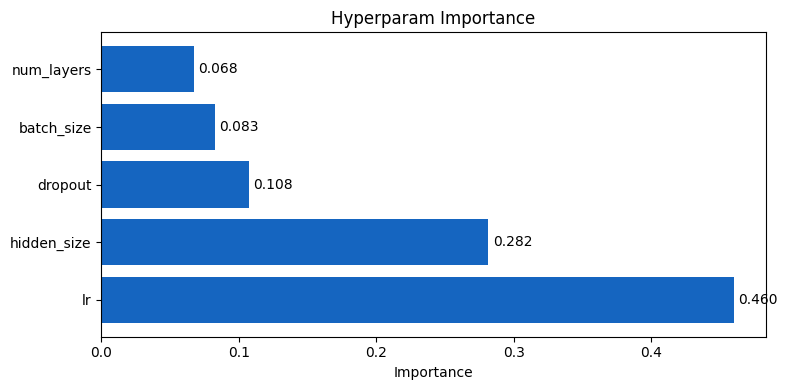

In [37]:
imp=optuna.importance.get_param_importances(study)
fig,ax=plt.subplots(figsize=(8,4))
b=ax.barh(list(imp.keys()),list(imp.values()),color="#1565C0")
ax.set_xlabel("Importance")
ax.set_title("Hyperparam Importance")
ax.bar_label(b,fmt="%.3f",padding=3)
plt.tight_layout()
plt.savefig("/kaggle/working/optuna_param_importance.png",dpi=150)
plt.show()

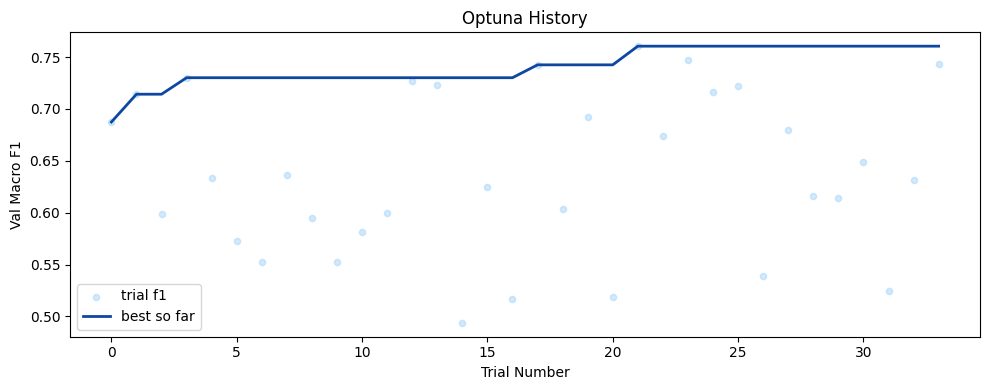

In [ ]:
done=[t for t in study.trials if t.state==optuna.trial.TrialState.COMPLETE]
nums=[t.number for t in done]
vals=[t.value for t in done]
bc=[max(vals[:i+1]) for i in range(len(vals))]
fig,ax=plt.subplots(figsize=(10,4))
ax.scatter(nums,vals,alpha=0.4,s=20,color="#90CAF9",label="trial f1")
ax.plot(nums,bc,color="#0D47A1",lw=2,label="best so far")
ax.set_xlabel("Trial Number"); ax.set_ylabel("Val Macro F1"); ax.set_title("Optuna History")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/optuna_history.png",dpi=150)
plt.show()